# Conditional 3D scale-up

Generate a categorical `128³` volume directly from a larger fully-convolutional SliceGAN noise grid. The 64×64 anchor images are placed as centered patches at their requested axes and indices; the volume is not made by interpolation or pattern repetition.

> This notebook is prepared but intentionally not executed in the base-quality milestone. A full 128³ quality run is substantially longer than the 64³ check.

In [1]:
from argparse import Namespace
from pathlib import Path
import sys
import time

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import display

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.app.api import AnchorSlice, PredictOptions
from src.app.runtime import (
    build_dataset,
    build_loader,
    load_defaults,
    load_predictor,
    load_slicegan_config,
)
from src.modeling.phases import quantize_phase

def take_slice(volume, axis, index):
    return np.take(volume, index, axis=axis)

## Parameters

`AnchorSlice.index` is always the absolute plane index in the output volume. The 64×64 condition image is centered within that plane without shifting the requested index.

In [2]:
RUN_DIR = 'run/20260712-163751-714469'
SCALE_SIZE = 128
PHASE_FRACTIONS = (0.28, 0.12, 0.60)
SAVE_RESULT = True
USE_SAVED_RESULT = True
slicegan_config = load_slicegan_config(ROOT / 'config' / 'slicegan.yaml')

options_kwargs = dict(
    slicegan=slicegan_config,
    phase_fractions=PHASE_FRACTIONS,
    phase_fraction_tolerance=0.01,
)

## Predict

In [3]:
run_dir = ROOT / RUN_DIR
result_path = run_dir / 'predictions' / f'conditional_slicegan_{SCALE_SIZE}.npz'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
args = Namespace(**load_defaults(run_dir / 'vae.yaml'))
args.data_dir = ROOT / args.data_dir
args.batch_size = 1

batch = next(build_loader(build_dataset(args), args, device=torch.device('cpu')))
anchor_image = quantize_phase(batch[0, 0], args.num_phases).numpy()
base_size = anchor_image.shape[0]
anchor_index = SCALE_SIZE // 2
condition_start = (SCALE_SIZE - base_size) // 2
anchors = [
    AnchorSlice(image=anchor_image, axis=0, index=anchor_index),
    AnchorSlice(image=anchor_image.copy(), axis=1, index=anchor_index),
]
options = PredictOptions(num_phases=args.num_phases, **options_kwargs)

if USE_SAVED_RESULT:
    if not result_path.is_file():
        raise FileNotFoundError(f'saved result does not exist: {result_path}')
    with np.load(result_path, allow_pickle=False) as saved:
        expected_axes = np.array([anchor.axis for anchor in anchors])
        expected_indices = np.array([anchor.index for anchor in anchors])
        if not np.array_equal(saved['anchor_axes'], expected_axes):
            raise ValueError('saved anchor axes do not match current anchors.')
        if not np.array_equal(saved['anchor_indices'], expected_indices):
            raise ValueError('saved absolute anchor indices do not match current anchors.')
        if not np.allclose(saved['phase_fractions'], PHASE_FRACTIONS, atol=1e-7):
            raise ValueError('saved phase fractions do not match current options.')
        if not np.isclose(float(saved['phase_fraction_tolerance']), options.phase_fraction_tolerance):
            raise ValueError('saved phase-fraction tolerance does not match current options.')
        if not np.isclose(float(saved['anchor_intersection_tolerance']), slicegan_config.intersection_tolerance):
            raise ValueError('saved anchor-intersection tolerance does not match current options.')
        expected_steps = {
            'slicegan_steps': slicegan_config.training.steps,
            'slicegan_hybrid_steps': slicegan_config.training.hybrid_steps,
            'slicegan_condition_steps': slicegan_config.conditioning.steps,
            'slicegan_finetune_steps': slicegan_config.conditioning.finetune_steps,
        }
        for key, expected in expected_steps.items():
            if int(saved[key]) != expected:
                raise ValueError(f'saved {key} does not match current options.')
        volume_np = saved['volume'].copy()
        if volume_np.shape != (SCALE_SIZE, SCALE_SIZE, SCALE_SIZE):
            raise ValueError('saved volume shape does not match SCALE_SIZE.')
        stats = {
            key.removeprefix('stat__'): torch.from_numpy(saved[key].copy())
            for key in saved.files
            if key.startswith('stat__')
        }
        anchors = [
            AnchorSlice(image=image.copy(), axis=int(axis), index=int(index))
            for image, axis, index in zip(
                saved['anchor_images'],
                saved['anchor_axes'],
                saved['anchor_indices'],
            )
        ]
        anchor_image = anchors[0].image
    volume = torch.from_numpy(volume_np)
    elapsed_seconds = float(stats['slicegan_total_seconds'])
    print('loaded:', result_path)
else:
    predictor = load_predictor(run_dir, device=device)
    start_time = time.perf_counter()
    volume, stats = predictor.predict(options, anchors=anchors, volume_size=SCALE_SIZE)
    elapsed_seconds = time.perf_counter() - start_time
    volume_np = volume.cpu().numpy()

absolute_anchors = [(anchor.axis, anchor.index) for anchor in anchors]
print('device:', device)
print(f'elapsed: {elapsed_seconds:.1f} seconds')
print('volume:', volume_np.shape, volume.dtype)
print('anchor patch start:', condition_start)
print('absolute anchors:', absolute_anchors)
print('selected training step:', int(stats['slicegan_selected_step']))
print('fully convolutional:', bool(stats['slicegan_fully_convolutional']))
print(f"reference preparation: {float(stats['slicegan_reference_seconds']):.1f} seconds")
print(f"texture training: {float(stats['slicegan_training_seconds']):.1f} seconds")
print(f"conditional generation: {float(stats['slicegan_generation_seconds']):.1f} seconds")
print('anchor mismatches:', np.round(stats['slicegan_anchor_mismatches'].cpu().numpy(), 4).tolist())
print('target phase fraction:', np.round(stats['slicegan_target_phase_fraction'].cpu().numpy(), 4).tolist())
print('volume phase fraction:', np.round(stats['slicegan_phase_fraction'].cpu().numpy(), 4).tolist())
print('axis run-profile MAE:', np.round(stats['slicegan_diagnostic_axis_run_profile_mae'].cpu().numpy(), 4).tolist())
print('axis Euler MAE:', np.round(stats['slicegan_diagnostic_axis_euler_mae'].cpu().numpy(), 4).tolist())
print('axis lag-3 change:', np.round(stats['slicegan_diagnostic_axis_lag3_change_rate'].cpu().numpy(), 4).tolist())
print('exact repeated-slice rate:', np.round(stats['slicegan_diagnostic_axis_exact_repeat_rate'].cpu().numpy(), 4).tolist())
print('global boundary jump:', np.round(stats['slicegan_diagnostic_axis_global_boundary_jump'].cpu().numpy(), 4).tolist())
if SAVE_RESULT and not USE_SAVED_RESULT:
    result_dir = run_dir / 'predictions'
    result_dir.mkdir(parents=True, exist_ok=True)
    payload = {
        'volume': volume_np,
        'anchor_images': np.stack([anchor.image for anchor in anchors]),
        'anchor_axes': np.array([anchor.axis for anchor in anchors], dtype=np.int64),
        'anchor_indices': np.array([anchor.index for anchor in anchors], dtype=np.int64),
        'phase_fractions': np.asarray(PHASE_FRACTIONS, dtype=np.float32),
        'phase_fraction_tolerance': np.array(options.phase_fraction_tolerance, dtype=np.float32),
        'anchor_intersection_tolerance': np.array(slicegan_config.intersection_tolerance, dtype=np.float32),
        'slicegan_steps': np.array(slicegan_config.training.steps, dtype=np.int64),
        'slicegan_hybrid_steps': np.array(slicegan_config.training.hybrid_steps, dtype=np.int64),
        'slicegan_condition_steps': np.array(slicegan_config.conditioning.steps, dtype=np.int64),
        'slicegan_finetune_steps': np.array(slicegan_config.conditioning.finetune_steps, dtype=np.int64),
    }
    payload.update({
        f'stat__{key}': value.detach().cpu().numpy()
        for key, value in stats.items()
        if torch.is_tensor(value)
    })
    np.savez_compressed(result_path, **payload)
    with np.load(result_path, allow_pickle=False) as saved:
        assert saved['volume'].shape == (SCALE_SIZE, SCALE_SIZE, SCALE_SIZE)
        assert np.array_equal(saved['anchor_axes'], np.array([anchor.axis for anchor in anchors]))
        assert np.array_equal(saved['anchor_indices'], np.array([anchor.index for anchor in anchors]))
    print('saved and verified:', result_path)

loaded: D:\code\microlad\run\20260712-163751-714469\predictions\conditional_slicegan_128.npz
device: cuda
elapsed: 1600.9 seconds
volume: (128, 128, 128) torch.uint8
anchor patch start: 32
absolute anchors: [(0, 64), (1, 64)]
selected training step: 6000
fully convolutional: True
reference preparation: 15.4 seconds
texture training: 663.1 seconds
conditional generation: 922.4 seconds
anchor mismatches: [0.07500000298023224, 0.07450000196695328]
target phase fraction: [0.2800000011920929, 0.11999999731779099, 0.6000000238418579]
volume phase fraction: [0.2800000011920929, 0.11999999731779099, 0.6000000238418579]
axis run-profile MAE: [0.009600000455975533, 0.008500000461935997, 0.01140000019222498]
axis Euler MAE: [2.4763998985290527, 4.367000102996826, 2.3822999000549316]
axis lag-3 change: [0.40119999647140503, 0.40869998931884766, 0.4004000127315521]
exact repeated-slice rate: [0.0, 0.0, 0.0]
global boundary jump: [0.028699999675154686, 0.03959999978542328, 0.025100000202655792]


## Quality check

The checks compare each generated center patch with its condition without requiring an exact copy, verify the global phase fraction, and inspect all three axes across the full 128³ volume.

anchor mismatches: [0.075, 0.0745]
target phase fraction: [0.28, 0.12, 0.6]
volume phase fraction: [0.28, 0.12, 0.6]
axis transition rate: [0.2554, 0.249, 0.2547]
axis run-profile MAE: [0.009600000455975533, 0.008500000461935997, 0.01140000019222498]
exact repeated-slice rate: [0.0, 0.0, 0.0]
global boundary jump: [0.028699999675154686, 0.03959999978542328, 0.025100000202655792]
quality gates: {'all anchors 3-10% different': True, 'phase fraction within tolerance': True, 'axis transition spread <= 0.03': True, 'no exactly repeated adjacent slices': True, 'global boundary jump <= 0.08': True, 'axis run-profile MAE <= 0.05': True}


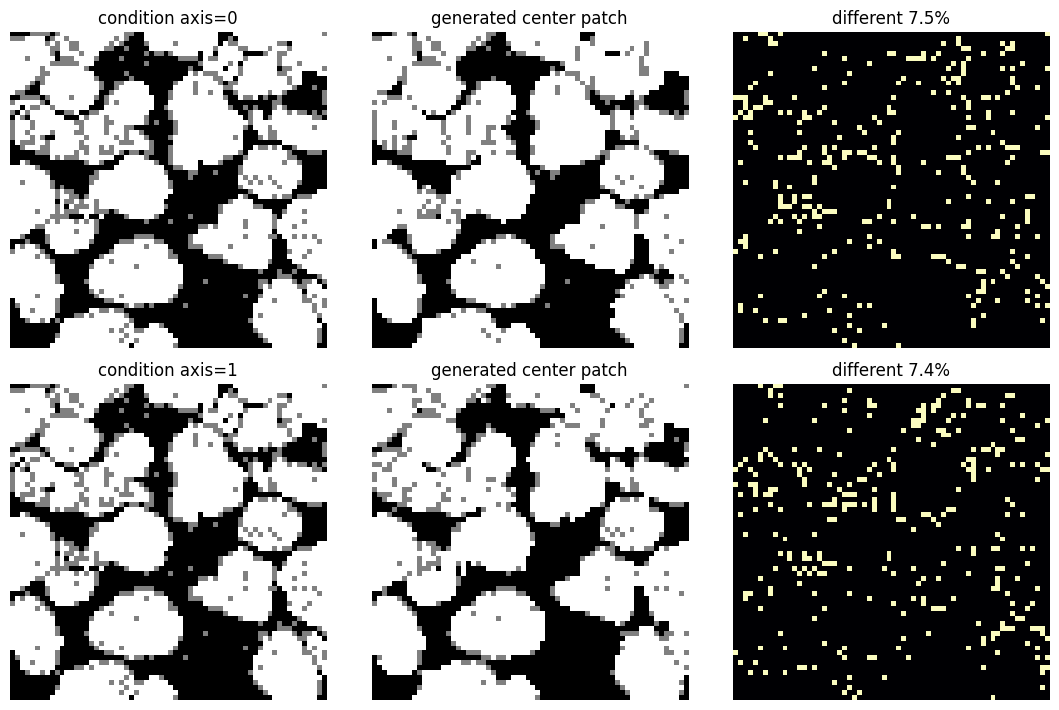

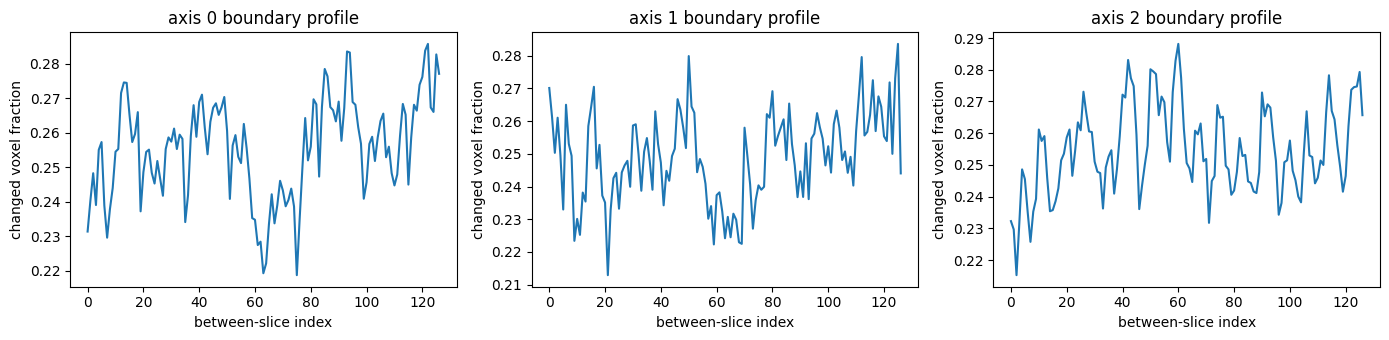

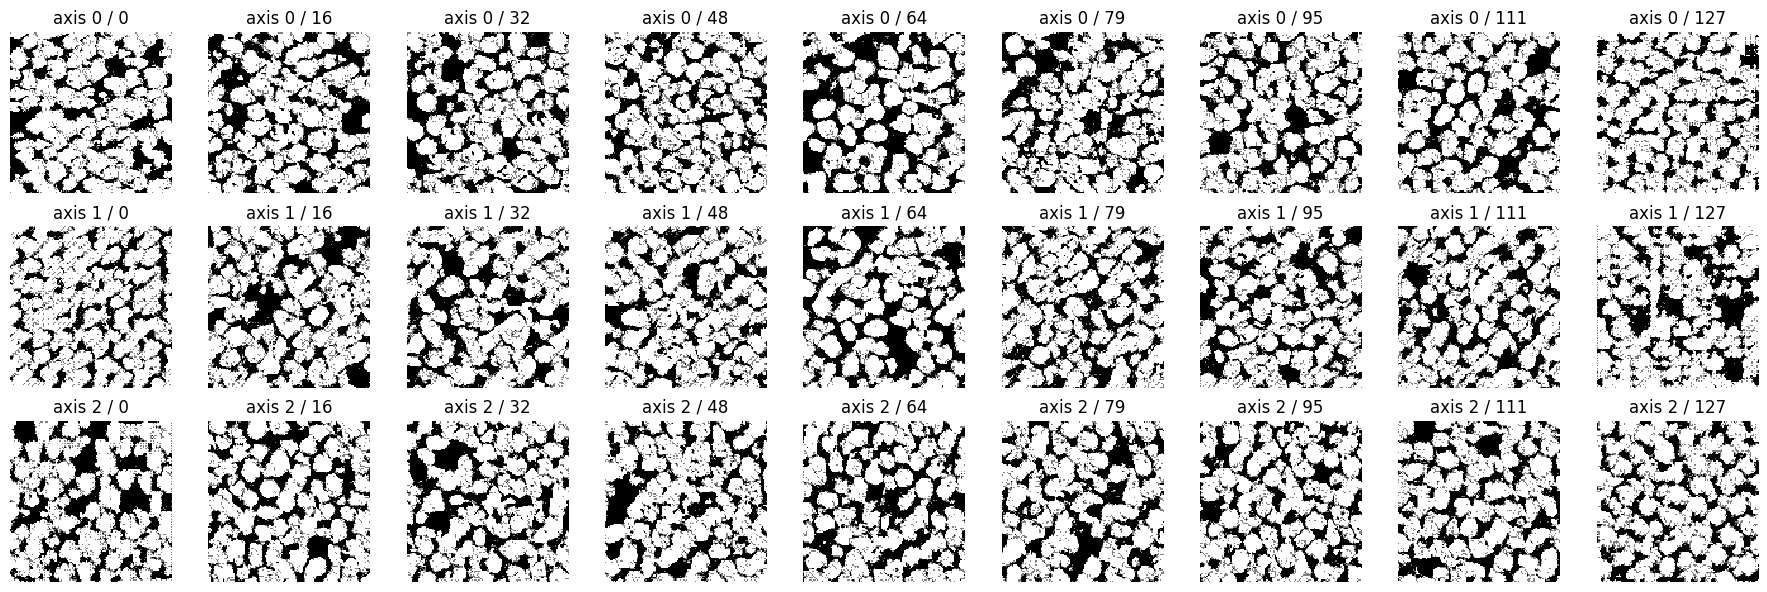

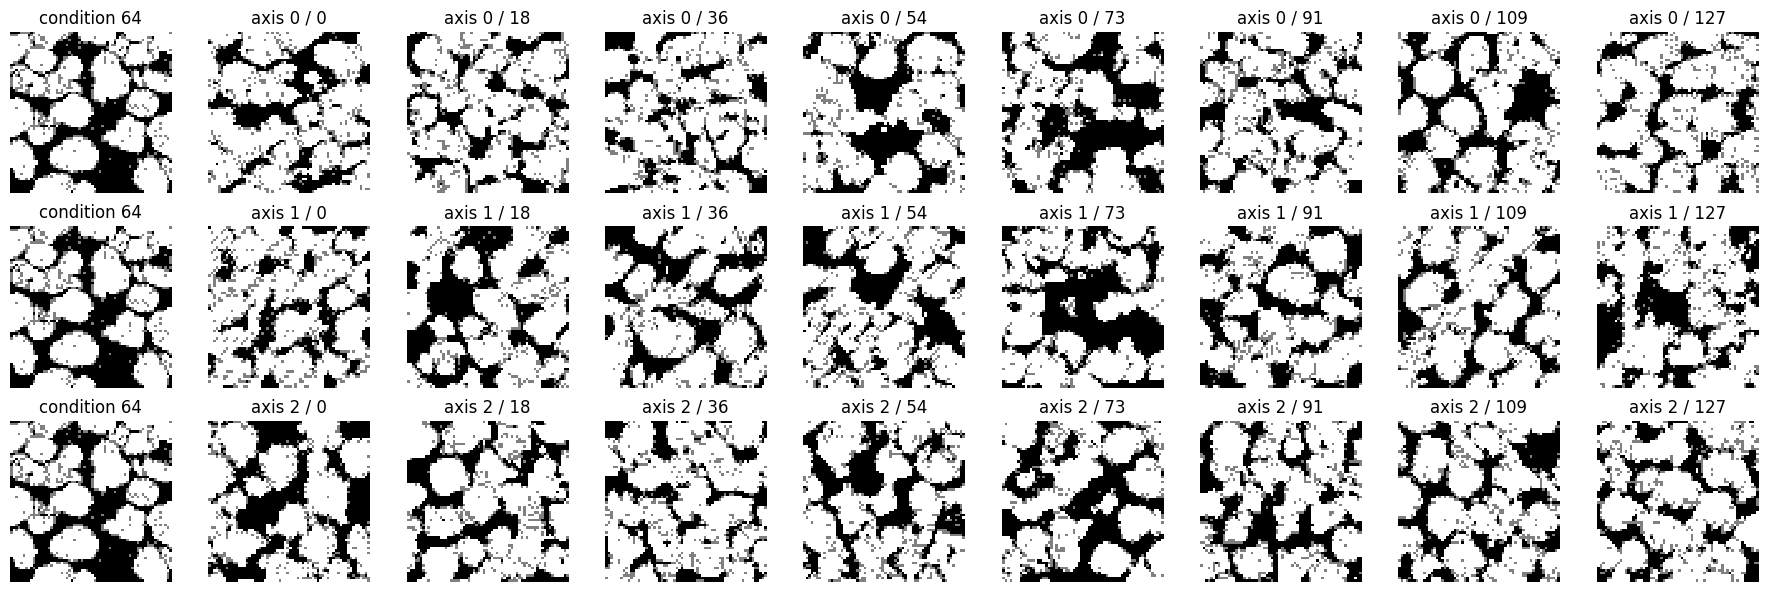

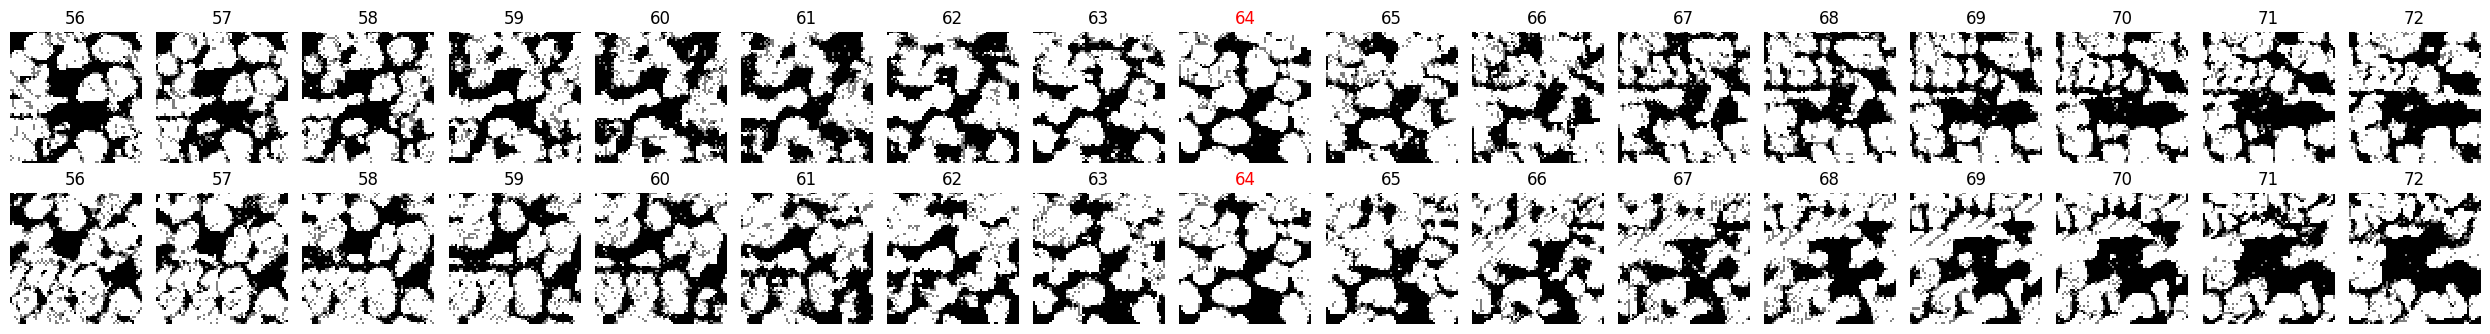

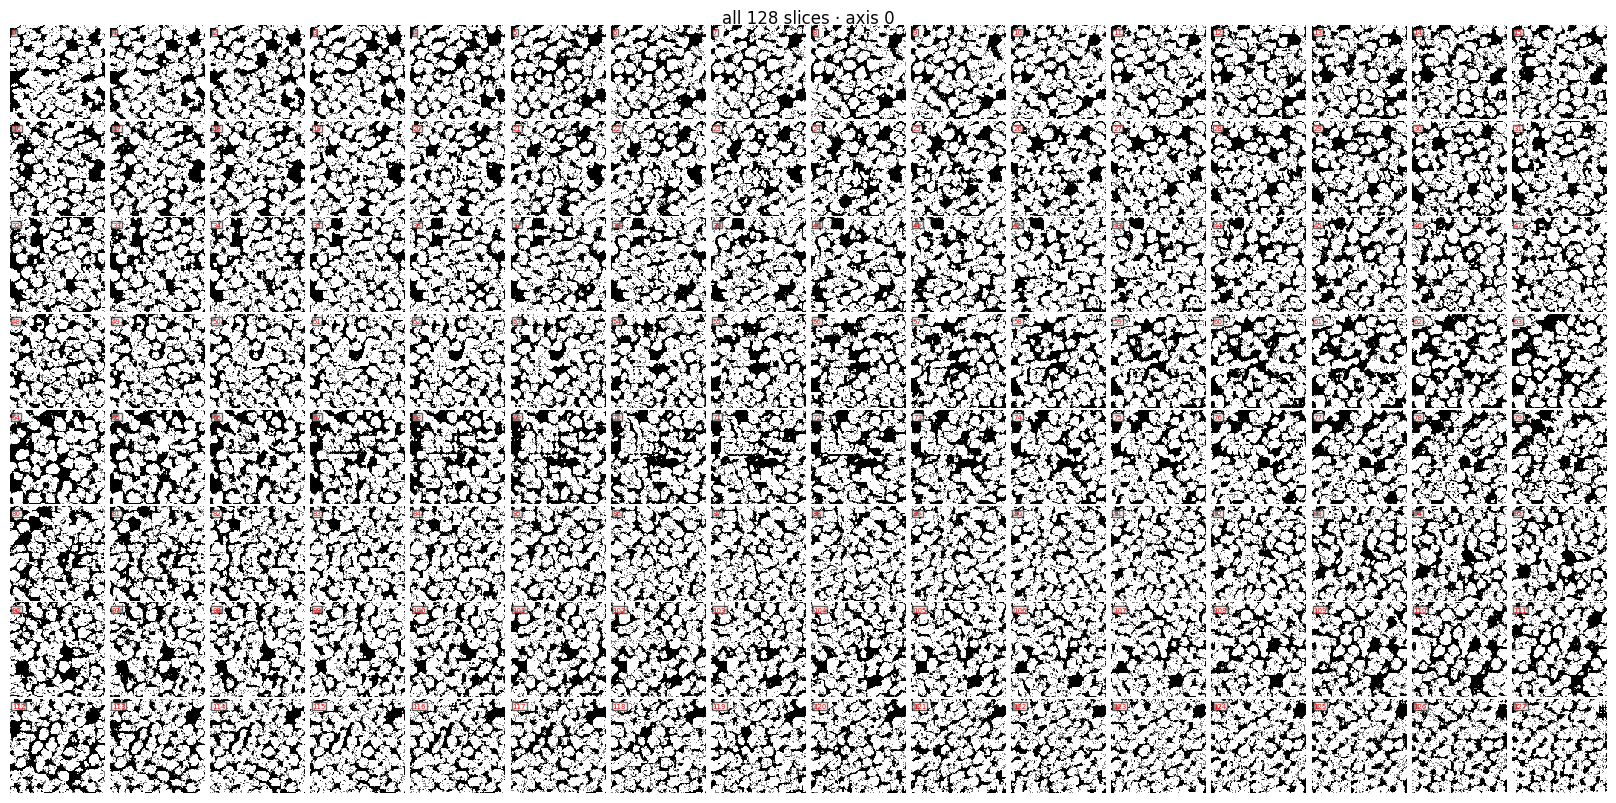

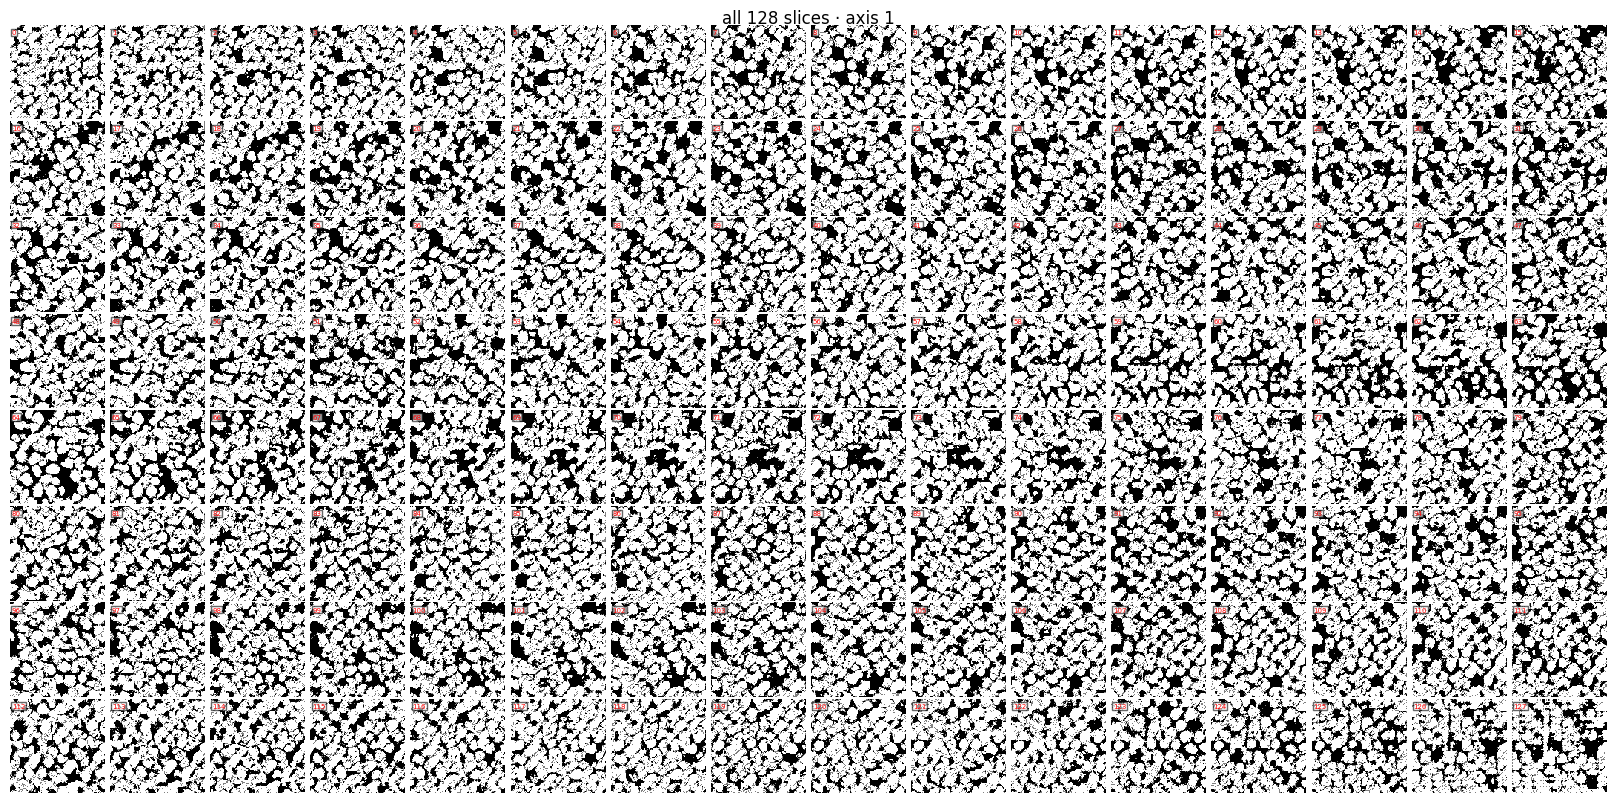

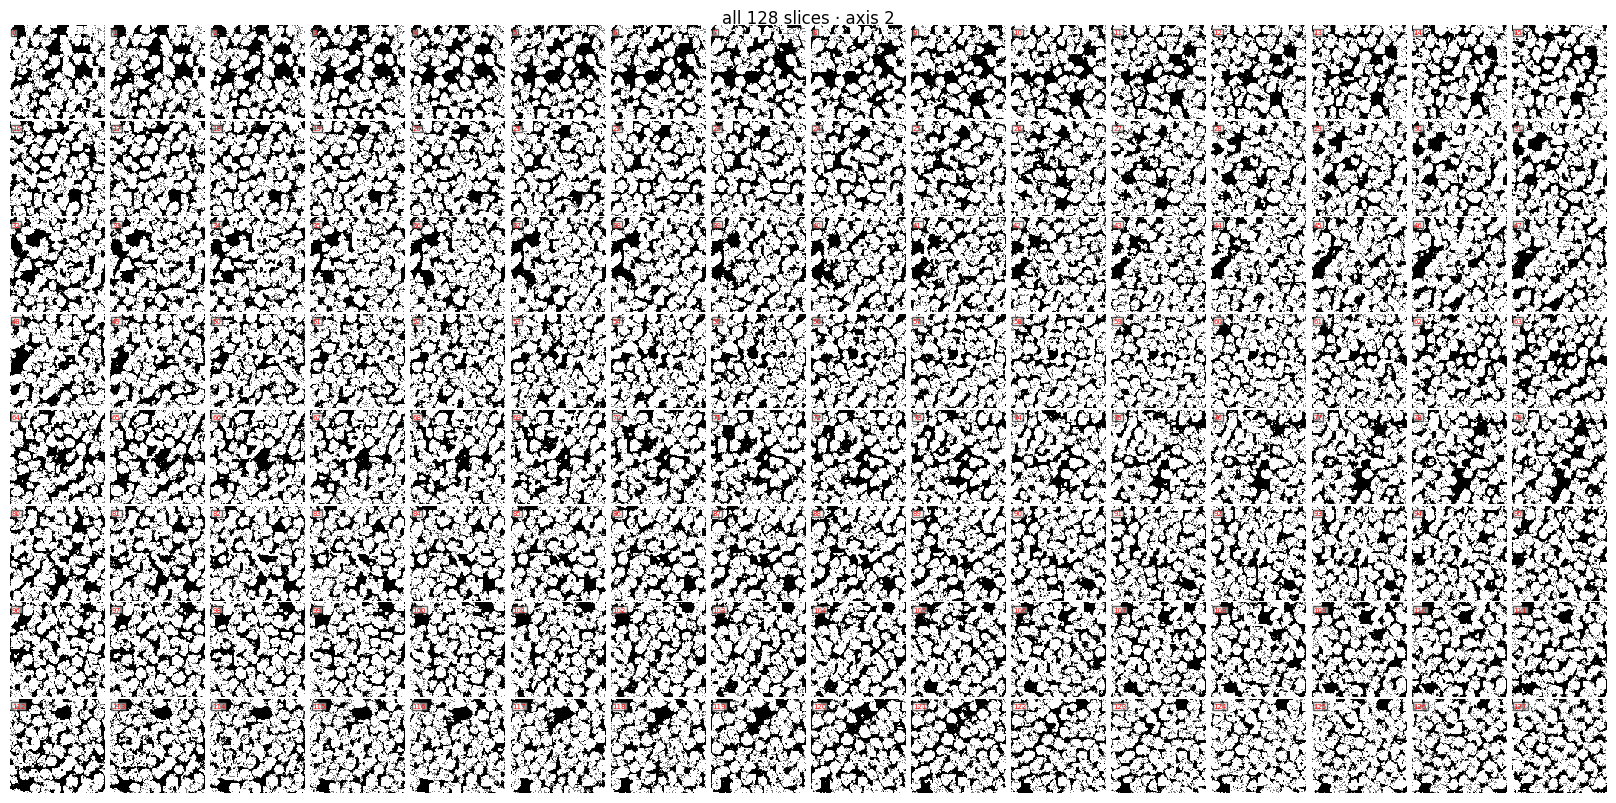

In [4]:
anchor_mismatches = []
generated_patches = []
for anchor in anchors:
    absolute_index = anchor.index
    plane = take_slice(volume_np, anchor.axis, absolute_index)
    patch = plane[
        condition_start : condition_start + base_size,
        condition_start : condition_start + base_size,
    ]
    generated_patches.append(patch)
    anchor_mismatches.append(np.mean(patch != anchor.image))

anchor_mismatches = np.asarray(anchor_mismatches)
volume_phase_fraction = np.array([
    np.mean(volume_np == phase) for phase in range(args.num_phases)
])
axis_transition_rate = np.array([
    np.mean(np.diff(volume_np, axis=axis) != 0) for axis in range(3)
])
axis_run_mae = stats['slicegan_diagnostic_axis_run_profile_mae'].cpu().numpy()
axis_exact_repeat = stats['slicegan_diagnostic_axis_exact_repeat_rate'].cpu().numpy()
axis_global_boundary_jump = stats['slicegan_diagnostic_axis_global_boundary_jump'].cpu().numpy()
boundary_profiles = []
for axis in range(3):
    changed = np.diff(volume_np, axis=axis) != 0
    reduce_axes = tuple(dimension for dimension in range(3) if dimension != axis)
    boundary_profiles.append(changed.mean(axis=reduce_axes))
quality_gates = {
    'all anchors 3-10% different': bool(np.all((anchor_mismatches >= 0.03) & (anchor_mismatches <= 0.10))),
    'phase fraction within tolerance': bool(np.max(np.abs(volume_phase_fraction - PHASE_FRACTIONS)) <= options.phase_fraction_tolerance),
    'axis transition spread <= 0.03': bool(np.ptp(axis_transition_rate) <= 0.03),
    'no exactly repeated adjacent slices': bool(np.max(axis_exact_repeat) == 0.0),
    'global boundary jump <= 0.08': bool(np.max(axis_global_boundary_jump) <= 0.08),
    'axis run-profile MAE <= 0.05': bool(np.max(axis_run_mae) <= 0.05),
}

print('anchor mismatches:', np.round(anchor_mismatches, 4).tolist())
print('target phase fraction:', list(PHASE_FRACTIONS))
print('volume phase fraction:', np.round(volume_phase_fraction, 4).tolist())
print('axis transition rate:', np.round(axis_transition_rate, 4).tolist())
print('axis run-profile MAE:', np.round(axis_run_mae, 4).tolist())
print('exact repeated-slice rate:', np.round(axis_exact_repeat, 4).tolist())
print('global boundary jump:', np.round(axis_global_boundary_jump, 4).tolist())
print('quality gates:', quality_gates)

fig, axes = plt.subplots(len(anchors), 3, figsize=(11, 3.6 * len(anchors)), squeeze=False)
for row, (anchor, generated) in enumerate(zip(anchors, generated_patches)):
    difference = generated != anchor.image
    items = [
        (anchor.image, f'condition axis={anchor.axis}', 'gray', 0, args.num_phases - 1),
        (generated, f'generated center patch', 'gray', 0, args.num_phases - 1),
        (difference, f'different {anchor_mismatches[row]:.1%}', 'magma', 0, 1),
    ]
    for axis, (image, title, cmap, vmin, vmax) in zip(axes[row], items):
        axis.imshow(image, cmap=cmap, vmin=vmin, vmax=vmax, interpolation='nearest')
        axis.set_title(title)
        axis.axis('off')
plt.tight_layout()

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), squeeze=False)
for axis_id, (axis, profile) in enumerate(zip(axes.ravel(), boundary_profiles)):
    axis.plot(np.arange(profile.size), profile)
    axis.set_title(f'axis {axis_id} boundary profile')
    axis.set_xlabel('between-slice index')
    axis.set_ylabel('changed voxel fraction')
plt.tight_layout()

indices = np.linspace(0, SCALE_SIZE - 1, 9).round().astype(int)
fig, axes = plt.subplots(3, len(indices), figsize=(18, 6))
for row, axis_id in enumerate(range(3)):
    for column, index in enumerate(indices):
        axes[row, column].imshow(take_slice(volume_np, axis_id, index), cmap='gray', vmin=0, vmax=args.num_phases - 1, interpolation='nearest')
        axes[row, column].set_title(f'axis {axis_id} / {index}')
        axes[row, column].axis('off')
plt.tight_layout()

comparison_indices = np.linspace(0, SCALE_SIZE - 1, 8).round().astype(int)
fig, axes = plt.subplots(3, len(comparison_indices) + 1, figsize=(18, 6), squeeze=False)
for row, axis_id in enumerate(range(3)):
    axes[row, 0].imshow(anchor_image, cmap='gray', vmin=0, vmax=args.num_phases - 1, interpolation='nearest')
    axes[row, 0].set_title('condition 64')
    axes[row, 0].axis('off')
    for column, index in enumerate(comparison_indices, start=1):
        image = take_slice(volume_np, axis_id, index)[condition_start : condition_start + base_size, condition_start : condition_start + base_size]
        axes[row, column].imshow(image, cmap='gray', vmin=0, vmax=args.num_phases - 1, interpolation='nearest')
        axes[row, column].set_title(f'axis {axis_id} / {index}')
        axes[row, column].axis('off')
plt.tight_layout()

continuity_offsets = range(-8, 9)
fig, axes = plt.subplots(len(anchors), len(continuity_offsets), figsize=(25, 3.5), squeeze=False)
for row, anchor in enumerate(anchors):
    for column, offset in enumerate(continuity_offsets):
        index = anchor.index + offset
        image = take_slice(volume_np, anchor.axis, index)[condition_start : condition_start + base_size, condition_start : condition_start + base_size]
        axes[row, column].imshow(image, cmap='gray', vmin=0, vmax=args.num_phases - 1, interpolation='nearest')
        axes[row, column].set_title(str(index), color='red' if offset == 0 else 'black')
        axes[row, column].axis('off')
plt.tight_layout()

for axis_id in range(3):
    fig, axes = plt.subplots(8, 16, figsize=(16, 8), squeeze=False)
    for index, axis in enumerate(axes.ravel()):
        axis.imshow(take_slice(volume_np, axis_id, index), cmap='gray', vmin=0, vmax=args.num_phases - 1, interpolation='nearest')
        axis.text(2, 12, str(index), fontsize=5, color='red', bbox={'facecolor': 'white', 'alpha': 0.6, 'pad': 0.5})
        axis.axis('off')
    fig.suptitle(f'all 128 slices · axis {axis_id}')
    plt.subplots_adjust(0, 0, 1, 0.96, wspace=0.02, hspace=0.02)
    plt.show()

## 3D slice browser

Choose an axis and move the slider to inspect every generated slice.

In [5]:
axis_selector = widgets.ToggleButtons(options=[('XY', 0), ('XZ', 1), ('YZ', 2)], value=0, description='axis')
index_slider = widgets.IntSlider(value=SCALE_SIZE // 2, min=0, max=SCALE_SIZE - 1, step=1, description='index', continuous_update=False)

def show_slice(axis, index):
    plt.figure(figsize=(5, 5))
    plt.imshow(take_slice(volume_np, axis, index), cmap='gray', vmin=0, vmax=args.num_phases - 1, interpolation='nearest')
    plt.title(f'axis {axis} · index {index}')
    plt.axis('off')
    plt.show()

slice_output = widgets.interactive_output(show_slice, {'axis': axis_selector, 'index': index_slider})
display(widgets.HBox([axis_selector, index_slider]), slice_output)

Output()